In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import copy
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import wandb
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json

from src.utils.plotting_style import set_figure_size

In [6]:
def get_runs_from_sweep(sweep_id):
    # Initialize wandb API
    api = wandb.Api()

    # Set your wandb project and entity
    entity = "agt-team"
    project = "certified-continual-learning"

    # Query all runs from the specified sweep
    runs = api.sweep(f"{entity}/{project}/{sweep_id}").runs

    print(f"Found {len(runs)} runs in sweep {sweep_id}")

    # Dictionary to store the accuracy matrices
    accuracy_matrices = {}

    # Load accuracy_matrix from each run
    for run in tqdm(runs, desc="Loading accuracy matrices"):
        try:
            # Get run files
            files = run.files()
            
            # Find accuracy matrix file
            accuracy_file = next((f for f in files if "accuracy_matrix" in f.name), None)
            
            if accuracy_file:
                # Download the file
                accuracy_file.download(replace=True)
                
                # For W&B table JSON files
                with open(accuracy_file.name, 'r') as f:
                    data = json.load(f)
                    # Extract the data from the W&B table format
                    if 'data' in data:
                        # Depending on how the table is structured, you might need to adjust this
                        matrix_data = data['data']
                        accuracy_matrix = np.array(matrix_data)
                        
                        # Store with run name/ID as key
                        accuracy_matrices[run.name] = accuracy_matrix
                    else:
                        print(f"Couldn't parse table data for {run.name}")
            else:
                print(f"No accuracy matrix found for {run.name}")
        except Exception as e:
            print(f"Error loading accuracy matrix for {run.name}: {e}")

    print(f"Successfully loaded {len(accuracy_matrices)} accuracy matrices")

def get_run_from_id(run_id, keys):
    # Initialize wandb API
    api = wandb.Api()

    # Set your wandb project and entity
    entity = "agt-team"
    project = "certified-continual-learning"

    # Get the run by its ID
    try:
        run = api.run(f"{entity}/{project}/{run_id}")
        print(f"Successfully retrieved run: {run.name}")
        
        # Get run files
        files = run.files()
        
        results = {}
        
        for key in keys:
            # Find accuracy matrix file
            accuracy_file = next((f for f in files if key in f.name), None)
            
            if accuracy_file:
                # Download the file
                accuracy_file.download(exist_ok=True)
                
                # For W&B table JSON files
                with open(accuracy_file.name, 'r') as f:
                    data = json.load(f)
                    # Extract the data from the W&B table format
                    if 'data' in data:
                        matrix_data = data['data']
                        results[key] = np.array(matrix_data)
                    else:
                        print(f"Couldn't parse table data for {run.name}")
            else:
                print(f"No accuracy matrix found for {run.name}")
                f
        return run, results
        
    except Exception as e:
        print(f"Error retrieving run {run_id}: {e}")
        return None, None
    
def get_runs_with_tags(tag, keys, n_runs=None):
    """
    Get runs with specific tag and extract specified keys from their files, storing the mean and std of the values.
    """
    # Initialize wandb API
    api = wandb.Api()
    # Set your wandb project and entity
    entity = "agt-team"
    project = "certified-continual-learning"
    # Query runs with the specified tag
    runs = api.runs(f"{entity}/{project}", {"tags": {"$all": tag if isinstance(tag, list) else [tag]}, "state": "finished"})
    print(f"Found {len(runs)} runs with tag '{tag}'")
    
    # Dictionary to store results for each key
    results = {key: [] for key in keys}
    
    if n_runs is not None:
        # Limit the number of runs to n_runs
        runs = runs[:n_runs]
        print(f"Limiting to the first {n_runs} runs")
    
    # Load data from each run
    for run in tqdm(runs, desc=f"Loading data from runs with tag '{tag}'"):
        try:
            # Get run files
            files = run.files()
            
            for key in keys:
                # Find file matching the current key
                found_file = next((f for f in files if key in f.name), None)
                
                if found_file:
                    # Download the file
                    found_file.download(exist_ok=True)
                    
                    # Load and parse the data
                    with open(found_file.name, 'r') as f:
                        data = json.load(f)
                        if 'data' in data:
                            matrix_data = data['data']
                            results[key].append(np.array(matrix_data))
                        else:
                            print(f"Couldn't parse data for {key} in run {run.name}")
                else:
                    print(f"No file found for {key} in run {run.name}")
        except Exception as e:
            print(f"Error processing run {run.name}: {e}")
    
    return results

In [187]:
def plot_accuracy_matrix_aggregated(run_results, width_scale=0.7, height_scale = 0.7):
    """
    Plot the accuracy averaged across all tasks and the accuracy on task 1.
    """

    width_pt = 397.48499  # document width in pt, as revealed by \showthe\textwidth in latex

    # Width of figure (in pts)
    fig_width_pt = width_pt
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**0.5 - 1) / 2
    # Figure width in inches
    fig_width_in = (fig_width_pt * inches_per_pt)
    fig_height_in = (fig_width_in / golden_ratio * (2/3))

    fig = plt.figure(layout="constrained", figsize=(fig_width_in * width_scale, fig_height_in * height_scale))  # Adjust size as needed
    width_ratios = [3, 1, 0, 0, 3, 1, 0, 0, 3, 1]
    height_ratios = [1, 0.4, 1]
    gs = gridspec.GridSpec(3, 10, figure=fig, width_ratios=width_ratios, height_ratios=height_ratios)  # 2 rows, 12 columns

    labels = {
        "accuracy_matrix": "PGD w/ LID",
        "accuracy_matrix_sgd": "SGD",
        "accuracy_matrix_ewc": "EWC",
        "accuracy_matrix_lwf": "LwF",
        "accuracy_matrix_ogd": "OGD",
        "accuracy_matrix_icn": "ICN"
    }

    buffer_labels = {
        "accuracy_agem": "A-GEM",
        'accuracy_none': "ZERO buf.",
        "accuracy_small": "SMALL buf.",
        "accuracy_medium": "MEDIUM buf.",
        "accuracy_large": "LARGE buf.",
    }

    axs = np.empty((2, 6), dtype=object)  # We'll pair 6 subplots (3 line + 3 bar, per row)
    # this is kind of a hack to get the titles centered
    titles = [
        "              Class IL                ",
        "             Domain IL            ",
        "              Task IL                ",
    ]

    for l, il_type in enumerate(["class", "domain", "task"]):
        col_base = 2 * l * 2  # 0, 4, 8
        ax_line_top = fig.add_subplot(gs[0, col_base])
        ax_bar_top = fig.add_subplot(gs[0, col_base + 1])
        ax_line_bottom = fig.add_subplot(gs[2, col_base])
        ax_bar_bottom = fig.add_subplot(gs[2, col_base + 1])
        axs[0, 2 * l] = ax_line_top
        axs[0, 2 * l + 1] = ax_bar_top
        axs[1, 2 * l] = ax_line_bottom
        axs[1, 2 * l + 1] = ax_bar_bottom

        ax_line_top.set_title(titles[l], y=1, loc="left", fontsize=8)

        if il_type not in run_results:
            continue

        names = ["accuracy_matrix_sgd", "accuracy_matrix_ewc", "accuracy_matrix_lwf", "accuracy_matrix_icn", "accuracy_matrix"]
        buffer_names = ["accuracy_agem", "accuracy_none", "accuracy_small", "accuracy_medium", "accuracy_large"]
        colors = ["C0", "C1", "C2", "C4", "C3"]
        for k, (name, color, buffer_name) in enumerate(zip(names, colors, buffer_names)):
            if name not in run_results[il_type]:
                continue
            accuracy_matrix = run_results[il_type][name]
            buffer_acc_matrix = run_results["buffer"][il_type][buffer_name]
            if isinstance(accuracy_matrix, list):
                avg_accs = [[np.mean([am[i][j] for j in range(i + 1)]).item() for i in range(5)] for am in accuracy_matrix]
                task_1_avg_accs = [[np.mean([am[i][j] for j in range(i + 1)]).item() for i in range(5)] for am in buffer_acc_matrix]
                avg_accs_array = np.array(avg_accs)
                task_1_accs_array = np.array(task_1_avg_accs)
                
                # Calculate mean
                avg_accs = np.mean(avg_accs_array, axis=0)
                task_1_accs = np.mean(task_1_accs_array, axis=0)
                
                # Calculate quartiles for error bars 
                q1_avg = np.percentile(avg_accs_array, 10, axis=0)
                q3_avg = np.percentile(avg_accs_array, 90, axis=0)
                avg_accs_yerr = ([avg_accs[-1] - q1_avg[-1]], [q3_avg[-1] - avg_accs[-1]])
                q1_task1 = np.percentile(task_1_accs_array, 10, axis=0)
                q3_task1 = np.percentile(task_1_accs_array, 90, axis=0)
                task_1_accs_yerr = ([task_1_accs[-1] - q1_task1[-1]], [q3_task1[-1] - task_1_accs[-1]])
                accuracy_matrix = np.array(accuracy_matrix).mean(axis=0)
                buffer_acc_matrix = np.array(buffer_acc_matrix).mean(axis=0)

                ax_line_top.plot(avg_accs, label=labels[name], color=color, linestyle="-")
                ax_line_bottom.plot(task_1_accs, label=buffer_labels[buffer_name], color=color, linestyle="-")

                ax_bar_top.bar(
                    k,
                    avg_accs[-1],
                    yerr=avg_accs_yerr[-1],
                    capsize=1.0,
                    error_kw={"lw": 0.5, "capthick": 0.5, "ecolor": f"grey"},
                    color=color,
                )
                ax_bar_bottom.bar(
                    k,
                    task_1_accs[-1],
                    yerr=task_1_accs_yerr[-1],
                    capsize=1.0,
                    error_kw={"lw": 0.5, "capthick": 0.5, "ecolor": f"grey"},
                    color=color,
                )

            else:
                avg_accs = [np.mean([accuracy_matrix[i][j] for j in range(i + 1)]) for i in range(5)]
                task_1_accs = [np.mean([buffer_acc_matrix[i][j] for j in range(i + 1)]) for i in range(5)]
                ax_line_top.plot(avg_accs, label=labels[name], color=color, linestyle="-")
                ax_line_bottom.plot(task_1_accs, label=buffer_labels[buffer_name], color=color, linestyle="-")
                ax_bar_top.bar(k, avg_accs[-1], color=color)
                ax_bar_bottom.bar(k, task_1_accs[-1], color=color)

            if name == "accuracy_matrix" or name == "accuracy_matrix_icn":
                accuracy_matrix[-1, -1] = accuracy_matrix[-2, -1]
                avg_certificates = [np.mean(accuracy_matrix[-1, : i + 1]) for i in range(5)]
                ax_line_top.plot(avg_certificates, linestyle="--", marker="", color=color)
                bar = ax_bar_top.bar(
                    k, avg_certificates[-1], width=0.8, color=color, lw=0.0, hatch="//////", edgecolor="darkred"
                )
            if buffer_name != "accuracy_agem":
                buffer_acc_matrix[-1, -1] = buffer_acc_matrix[-2, -1]
                task_1_certificate = [np.mean(buffer_acc_matrix[-1, : i + 1]) for i in range(5)]
                ax_line_bottom.plot(task_1_certificate, linestyle="--", marker="", color=color)
                ax_bar_bottom.bar(
                    k, task_1_certificate[-1], width=0.8, color=color, lw=0.0, hatch="//////", edgecolor="darkred"
                )

        ax_line_top.set_xticks(range(5))
        ax_line_top.set_xticklabels([])
        ax_line_bottom.set_xticks(range(5))
        ax_line_bottom.set_xticklabels([f"{i+1}" for i in range(5)])
        ax_bar_bottom.set_xticks([1.5])
        ax_bar_top.set_xticks([1.5])
        ax_bar_bottom.set_xticklabels(["Final"])
        ax_bar_top.set_xticklabels([])
        ax_bar_top.set_xlim(-0.8, 4.95)
        ax_bar_bottom.set_xlim(-0.8, 4.95)

    # Labels and limits
    axs[0, 0].set_ylabel("All Tasks")
    axs[1, 0].set_ylabel("All Tasks")
    axs[1, 0].set_ylim(0.0, 1.05)

    axs[1, 0].set_xlabel("       Train Task           ", loc="left", fontsize=10)
    axs[1, 2].set_xlabel("       Train Task           ", loc="left", fontsize=10)
    axs[1, 4].set_xlabel("       Train Task           ", loc="left", fontsize=10)

    for ax in axs.flatten():
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1], [])
        ax.set_ylim(0.0, 1.1)

    axs[0, 0].set_yticks([0, 0.25, 0.5, 0.75, 1], ["0", "", "", "", "1"])
    axs[1, 0].set_yticks([0, 0.25, 0.5, 0.75, 1], ["0", "", "", "", "1"])
    # Add grid and ticks
    for ax in axs.flatten():
        # Make minor ticks invisible
        ax.tick_params(which='minor', bottom=False, left=False, right=False, top=False)

    # Axis label
    fig.supylabel("Accuracy", fontsize=10)

    # Legend
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=5,
        frameon=True,
    )

    legend_ax = fig.add_subplot(gs[1, :])
    legend_ax.axis('off')

    handles, labels = axs[1, 0].get_legend_handles_labels()
    legend_ax.legend(
        handles,
        labels,
        loc="center",
        ncol=len(labels),
        frameon=True,
    )

    # set_figure_size(fig, 1, (2, 3), shrink_height=1.0)
    plt.savefig("figures/zero_buffer_mnist.pdf", dpi=600)

In [163]:
from collections import defaultdict

results = defaultdict(dict)

In [164]:
keys = ["accuracy_matrix_sgd", "accuracy_matrix_ewc", "accuracy_matrix"]
class_results = get_runs_with_tags("final_mnist_cil_new", keys)
results["class"] = class_results
results["class"]["accuracy_matrix_lwf"] = get_runs_with_tags("final_mnist_cil_lwf", keys=["accuracy_matrix_lwf"])["accuracy_matrix_lwf"]
results["class"]["accuracy_matrix_icn"] = get_runs_with_tags("final_mnist_cil_icn", keys=["accuracy_matrix_icn"])["accuracy_matrix_icn"]

task_results = get_runs_with_tags("final_mnist_til_new", keys)
results["task"] = task_results
results["task"]["accuracy_matrix_lwf"] = get_runs_with_tags("final_mnist_til_lwf", keys=["accuracy_matrix_lwf"])["accuracy_matrix_lwf"]
results["task"]["accuracy_matrix_icn"] = get_runs_with_tags("final_mnist_til_icn", keys=["accuracy_matrix_icn"])["accuracy_matrix_icn"]

domain_results = get_runs_with_tags("final_mnist_dil_new", keys)
results["domain"] = domain_results
results["domain"]["accuracy_matrix_lwf"] = get_runs_with_tags("final_mnist_dil_lwf", keys=["accuracy_matrix_lwf"])["accuracy_matrix_lwf"]
results["domain"]["accuracy_matrix_icn"] = get_runs_with_tags("final_mnist_dil_icn", keys=["accuracy_matrix_icn"])["accuracy_matrix_icn"]

Found 100 runs with tag 'final_mnist_cil_new'


Loading data from runs with tag 'final_mnist_cil_new': 100%|██████████████████████████████████████████████████████████████| 100/100 [00:27<00:00,  3.67it/s]


Found 100 runs with tag 'final_mnist_cil_lwf'


Loading data from runs with tag 'final_mnist_cil_lwf': 100%|██████████████████████████████████████████████████████████████| 100/100 [00:26<00:00,  3.76it/s]


Found 70 runs with tag 'final_mnist_cil_icn'


...

Loading data from runs with tag 'final_mnist_dil_new': 100%|████████████████████████████████████████████████████████████████| 85/85 [00:22<00:00,  3.73it/s]


Found 85 runs with tag 'final_mnist_dil_lwf'


Loading data from runs with tag 'final_mnist_dil_lwf': 100%|████████████████████████████████████████████████████████████████| 85/85 [00:21<00:00,  4.03it/s]


Found 100 runs with tag 'final_mnist_dil_icn'


Loading data from runs with tag 'final_mnist_dil_icn': 100%|██████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.89it/s]


In [165]:
keys = ["accuracy_matrix"]
results["buffer"] = defaultdict(dict)
class_results = get_runs_with_tags(["final_mnist_cil_new"], keys)
results["buffer"]["class"]["accuracy_none"] = class_results["accuracy_matrix"][:5]
class_results = get_runs_with_tags(["buffer_cil", "buffer_small"], keys)
results["buffer"]["class"]["accuracy_small"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_cil", "buffer_medium"], keys)
results["buffer"]["class"]["accuracy_medium"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_cil", "buffer_large"], keys)
results["buffer"]["class"]["accuracy_large"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_cil", "buffer_agem"], keys)
results["buffer"]["class"]["accuracy_agem"] = class_results["accuracy_matrix"]

class_results = get_runs_with_tags(["final_mnist_til_new"], keys)
results["buffer"]["task"]["accuracy_none"] = class_results["accuracy_matrix"][:5]
class_results = get_runs_with_tags(["buffer_til", "buffer_small"], keys)
results["buffer"]["task"]["accuracy_small"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_til", "buffer_medium"], keys)
results["buffer"]["task"]["accuracy_medium"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_til", "buffer_large"], keys)
results["buffer"]["task"]["accuracy_large"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_til", "buffer_agem"], keys)
results["buffer"]["task"]["accuracy_agem"] = class_results["accuracy_matrix"]


class_results = get_runs_with_tags(["final_mnist_dil_new"], keys)
results["buffer"]["domain"]["accuracy_none"] = class_results["accuracy_matrix"][:5]
class_results = get_runs_with_tags(["buffer_dil", "buffer_small"], keys)
results["buffer"]["domain"]["accuracy_small"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_dil", "buffer_medium"], keys)
results["buffer"]["domain"]["accuracy_medium"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_dil", "buffer_large"], keys)
results["buffer"]["domain"]["accuracy_large"] = class_results["accuracy_matrix"]
class_results = get_runs_with_tags(["buffer_dil", "buffer_agem"], keys)
results["buffer"]["domain"]["accuracy_agem"] = class_results["accuracy_matrix"]

Found 100 runs with tag '['final_mnist_cil_new']'


Loading data from runs with tag '['final_mnist_cil_new']': 100%|██████████████████████████████████████████████████████████| 100/100 [00:26<00:00,  3.79it/s]


Found 5 runs with tag '['buffer_cil', 'buffer_small']'


Loading data from runs with tag '['buffer_cil', 'buffer_small']': 100%|███████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.69it/s]


Found 5 runs with tag '['buffer_cil', 'buffer_medium']'


...

Loading data from runs with tag '['buffer_dil', 'buffer_medium']': 100%|██████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.07it/s]


Found 5 runs with tag '['buffer_dil', 'buffer_large']'


Loading data from runs with tag '['buffer_dil', 'buffer_large']': 100%|███████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.80it/s]


Found 4 runs with tag '['buffer_dil', 'buffer_agem']'


Loading data from runs with tag '['buffer_dil', 'buffer_agem']': 100%|████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  4.59it/s]


/tmp/ipykernel_2115632/394228318.py:194: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig("figures/zero_buffer_mnist.pdf", dpi=600)
/tmp/ipykernel_2115632/394228318.py:194: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig("figures/zero_buffer_mnist.pdf", dpi=600)
/vol/bitbucket/le24/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


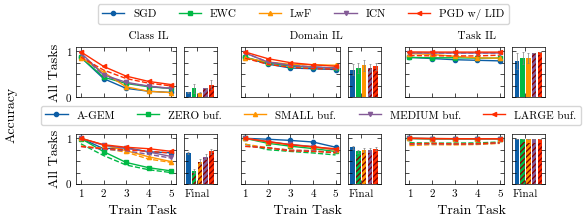

In [190]:
plot_accuracy_matrix_aggregated(results, 1.1, 0.3)